In [1]:
from explain import *
import pandas as pd
import explain.tools as explain_tools
from pathlib import Path

In [2]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine'

modelName = "Livingwithmachines/bert_1760_1900"
dataPath = 'input_data'
processedFolder = Path('gradient_data')
processedFolder.mkdir(exist_ok=True, parents=True)
predCol = "pred_bert_1760_1900"
iloc_range = (0, -1)

In [3]:
resultType = 'pred_kw_filtered' #'contrastive'

In [4]:
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t')
print(f'We have {df_sent.shape[0]} sentences for the target token {TargetMaskedToken} in the {collection} collection.')

We have 20119 sentences for the target token machine in the blb collection.


In [5]:
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target masked token {TargetMaskedToken}.')

We have 2415322 explanations for the target masked token machine.


In [6]:
def listindex(my_list, item):
    try:
        return my_list.index(item)
    except ValueError:
        return -1
    
# def listindexitem(my_tuples, item):
#     try:
#         return [s for k,s in my_tuples if k == item][0]
#     except (ValueError,IndexError) as e:
#         return -1
    
def listindexitem(my_tuples, item):
    return dict(my_tuples).get(item, -1)

In [7]:
print('Normalizing the scores for each sentence...')
df_ig['Score_normalized'] = df_ig.groupby('id')['Score'].transform(
    lambda x: x / x.abs().sum() if x.abs().sum() > 0 else x
)

print('Adding mask syntax relation and token distance features...')
df_ig = explain_tools.add_mask_syntax_relation(df_ig)
df_ig = explain_tools.add_mask_token_distance(df_ig)

print('Adding target position feature...')
df_ig['Target_position'] = df_ig.apply(
    lambda row: listindex(
        [k for k,s in eval(df_sent.iloc[row['id']].pred_bert_1760_1900)], row['Target']
            ), axis=1
        )




Normalizing the scores for each sentence...
Adding mask syntax relation and token distance features...


Token distance: 100%|██████████| 57142/57142 [00:14<00:00, 3929.45it/s]


Adding target position feature...


In [8]:
from tqdm import tqdm
tqdm.pandas(desc="Adding target score feature...")
df_ig['Target_score'] = df_ig.apply(
    lambda row: listindexitem(
        eval(df_sent.iloc[row['id']].pred_bert_1760_1900), row['Target']
            ), axis=1
        )


<Axes: title={'center': 'Distribution of target token scores'}, xlabel='Target token score', ylabel='Frequency'>

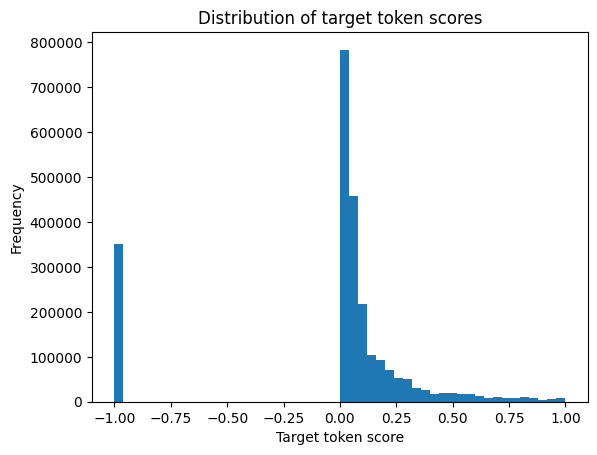

In [9]:
df_ig['Target_score'].plot(kind='hist', bins=50, title='Distribution of target token scores', xlabel='Target token score', ylabel='Frequency')

In [10]:
df_ig['Sentence_length'] = df_ig.groupby('id')['Score'].transform(
    lambda x: len(x)
)

In [11]:
df_ig.to_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv')